In [1]:
%pip install rdrobust rddensity statsmodels pandas numpy matplotlib rpy2


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# RD packages (Python)
from rdrobust import rdplot, rdrobust

# Regression
import statsmodels.formula.api as smf

# R interface
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, r
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects import pandas2ri
from sklearn.neighbors import NearestNeighbors

# Convenience alias
R = ro.r

pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 1000)

In [3]:
try:
    from rdrobust import rdrobust
    rd_available = True
except ImportError:
    rd_available = False

print("rdrobust available?", rd_available)

rdrobust available? True


In [4]:
data_2010 = pd.read_csv("Data/output/data-2010.csv")
data_2010.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106999 entries, 0 to 106998
Columns: 106 entries, contractid to year_bench
dtypes: float64(86), int64(3), object(17)
memory usage: 86.5+ MB


In [5]:
data_2011 = pd.read_csv("Data/output/data-2011.csv")
data_2011.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66544 entries, 0 to 66543
Columns: 110 entries, contractid to year_bench
dtypes: float64(90), int64(3), object(17)
memory usage: 55.8+ MB


In [6]:
data_2012 = pd.read_csv("Data/output/data-2012.csv")
data_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65891 entries, 0 to 65890
Columns: 111 entries, contractid to year_bench
dtypes: float64(84), int64(3), object(24)
memory usage: 55.8+ MB


In [7]:
data_2013 = pd.read_csv("Data/output/data-2013.csv")
data_2013.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66067 entries, 0 to 66066
Columns: 112 entries, contractid to year_bench
dtypes: float64(85), int64(3), object(24)
memory usage: 56.5+ MB


In [8]:
data_2014 = pd.read_csv("Data/output/data-2014.csv")
data_2014.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60497 entries, 0 to 60496
Columns: 110 entries, contractid to year_bench
dtypes: float64(83), int64(3), object(24)
memory usage: 50.8+ MB


In [9]:
data_2015 = pd.read_csv("Data/output/data-2015.csv")
data_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63626 entries, 0 to 63625
Columns: 107 entries, contractid to year_bench
dtypes: float64(82), int64(4), object(21)
memory usage: 51.9+ MB


In [10]:
data_2010["year"] = 2010
data_2011["year"] = 2011
data_2012["year"] = 2012
data_2013["year"] = 2013
data_2014["year"] = 2014
data_2015["year"] = 2015

In [11]:
data = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015], ignore_index=True)
print(list(data.columns))

['contractid', 'planid', 'fips', 'year_x', 'n_nonmiss', 'avg_enrollment', 'first_enrollment', 'last_enrollment', 'state', 'county', 'org_type', 'plan_type', 'partd', 'snp', 'eghp', 'org_name', 'org_marketing_name', 'plan_name', 'parent_org', 'contract_date', 'state_long', 'county_long', 'year_pen', 'n_elig', 'n_enrol', 'avg_eligibles', 'first_eligibles', 'last_eligibles', 'avg_enrolled', 'sd_enrolled', 'min_enrolled', 'max_enrolled', 'first_enrolled', 'last_enrolled', 'ssa', 'state_name', 'state_land', 'premium', 'premium_partc', 'premium_partd_basic', 'premium_partd_supp', 'premium_partd_total', 'partd_deductible', 'year_land', 'riskscore_partc', 'payment_partc', 'rebate_partc', 'year_y', 'payment_partd', 'directsubsidy_partd', 'reinsurance_partd', 'costsharing_partd', 'riskscore_partd', 'basic_premium', 'bid', 'breastcancer_screen', 'rectalcancer_screen', 'cv_diab_cholscreen', 'glaucoma_test', 'monitoring', 'flu_vaccine', 'pn_vaccine', 'physical_health', 'mental_health', 'osteo_test'

## Question 1

In [12]:
question_1 = data.copy()
question_1["Star_Rating"] = pd.to_numeric(question_1["Star_Rating"], errors="coerce")

# 1) One row per plan-year
plan_year = (
    question_1.groupby(["year", "contractid", "planid"], as_index=False)
     .agg(
         star_rating=("Star_Rating", "first"),
         enrollments=("avg_enrollment", "first")   # avg over the year (counts)
     )
     .dropna(subset=["enrollments"])
)

# 2) Plan market share within year (national share)
plan_year["market_share"] = (
    plan_year["enrollments"] /
    plan_year.groupby("year")["enrollments"].transform("sum")
)

# Additional column for total plans per year
# plan_counts = (
#     question_1
#     .groupby(["year", "fips"])["planid"]
#     .nunique()
#     .reset_index(name="num_unique_plans")
# )
# plan_counts.head()

# 3) Summary table: mean across plans by year
summary_stats = (
    plan_year.groupby("year", as_index=False)
            .agg(
                mean_star_rating=("star_rating", "mean"),
                mean_enrollments=("enrollments", "mean"),
                mean_market_share=("market_share", "mean"),
                num_plans=("planid", "size")
            )
)

summary_stats["mean_market_share"] = 100 * summary_stats["mean_market_share"]
summary_stats

,year,mean_star_rating,mean_enrollments,mean_market_share,num_plans
0,2010,3.297851,541.619686,0.043178,2316
1,2011,3.446735,683.471133,0.050787,1969
2,2012,3.515077,720.263580,0.050327,1987
3,2013,3.629148,804.411562,0.048100,2079
4,2014,3.847589,887.122858,0.047893,2088
5,2015,3.899580,1025.486025,0.048263,2072


## Question 2

In [13]:
question_2 = plan_year[plan_year["star_rating"].isna()].copy()
summary_stats2 = (
    question_2.groupby("year", as_index=False)
            .agg(
                mean_enrollments=("enrollments", "mean"),
                mean_market_share=("market_share", "mean"),
                num_plans=("planid", "size")
            )
)

summary_stats2["mean_market_share"] = 100 * summary_stats2["mean_market_share"]
summary_stats2

,year,mean_enrollments,mean_market_share,num_plans
0,2010,152.181687,0.012132,827
1,2011,229.801326,0.017076,514
2,2012,201.718508,0.014095,362
3,2013,228.028250,0.013635,271
4,2014,319.598975,0.017254,346
5,2015,500.677744,0.023563,404


## Question 3

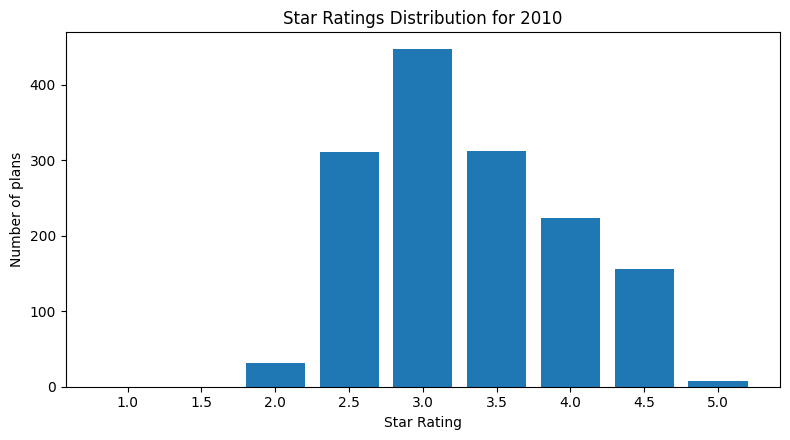

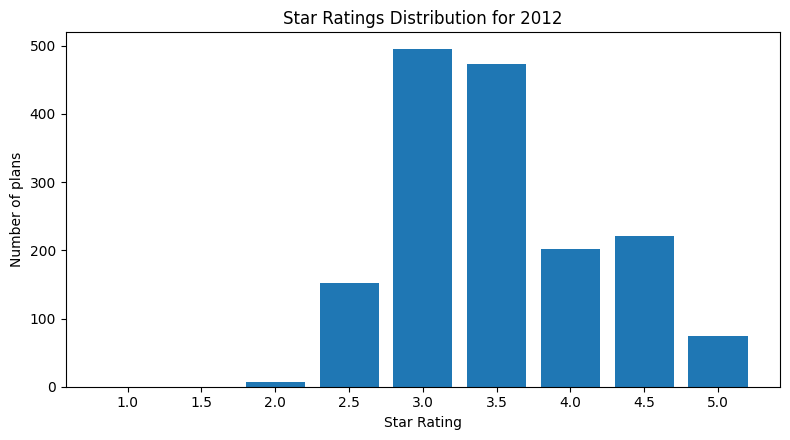

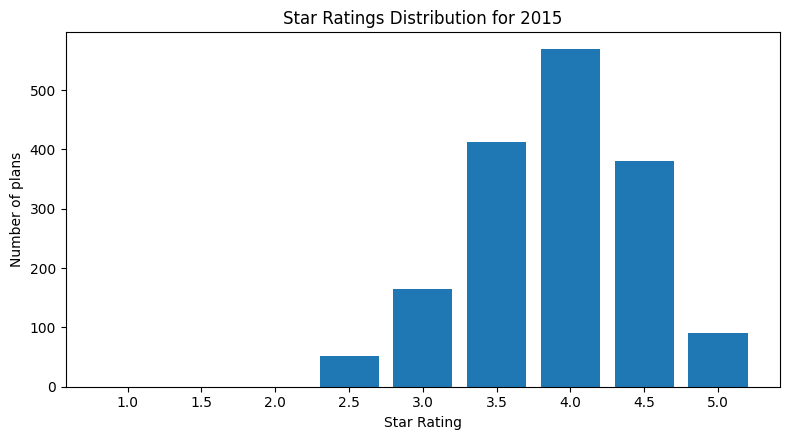

In [14]:
def plot_star_dist(df, year):
    s = df.loc[df["year"] == year, "star_rating"].dropna()

    bins = np.arange(1.0, 5.5 + 0.5, 0.5)
    labels = [f"{b:.1f}" for b in np.arange(1.0, 5.0 + 0.5, 0.5)]
    binned = pd.cut(s, bins=bins, right=False, include_lowest=True, labels=labels)
    counts = binned.value_counts().reindex(labels, fill_value=0)

    plt.figure(figsize=(8, 4.5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Star Ratings Distribution for {year}")
    plt.xlabel("Star Rating")
    plt.ylabel("Number of plans")
    plt.tight_layout()
    plt.show()

    return counts

for y in [2010, 2012, 2015]:
    plot_star_dist(plan_year, y)

The star ratings have shifted to the right overtime, as plans become higher rated. The data has become more centered around 3.5 rather than 3.0. 

## Question 4

In [15]:
# Create raw star ratings 


# rating_variables.py

RATING_VARS = {
    2008: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diabetes_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "primaryaccess",
        "hospital_followup",
        "depression_followup",
        "nodelays",
        "carequickly",
        "overallrating_care",
        "overallrating_plan",
        "calltime",
        "doctor_communicate",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "antidepressant",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "betablocker",
        "appeals_timely",
        "appeals_review",
    ],
    2009: [
        "contractid",
        "org_type",
        "contract_name",
        "org_marketing",
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diabetes_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "osteo_test",
        "physical_monitor",
        "primaryaccess",
        "hospital_followup",
        "depression_followup",
        "nodelays",
        "carequickly",
        "overallrating_care",
        "overallrating_plan",
        "calltime",
        "doctor_communicate",
        "customer_service",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "antidepressant",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "betablocker",
        "bladder",
        "falling",
        "appeals_timely",
        "appeals_review",
    ],
    2010: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_diab_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "osteo_test",
        "physical_monitor",
        "primaryaccess",
        "osteo_manage",
        "diab_healthy",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "bladder",
        "falling",
        "nodelays",
        "doctor_communicate",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "complaints_plan",
        "appeals_timely",
        "appeals_review",
        "leave_plan",
        "audit_problems",
        "hold_times",
        "info_accuracy",
        "ttyt_available",
    ],
    2011: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "monitoring",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "osteo_test",
        "physical_monitor",
        "primaryaccess",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "copd_test",
        "bladder",
        "falling",
        "nodelays",
        "doctor_communicate",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "complaints_plan",
        "appeals_timely",
        "appeals_review",
        "corrective_action",
        "hold_times",
        "info_accuracy",
        "ttyt_available",
    ],
    2012: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "flu_vaccine",
        "pn_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "primaryaccess",
        "bmi_assess",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "complaints_plan",
        "access_problems",
        "leave_plan",
        "appeals_timely",
        "appeals_review",
        "ttyt_available",
    ],
    2013: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "flu_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "bmi_assess",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "coordination",
        "complaints_plan",
        "access_problems",
        "leave_plan",
        "improve",
        "appeals_timely",
        "appeals_review",
        "ttyt_available",
        "enroll_timely",
    ],
    2014: [
        "breastcancer_screen",
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "glaucoma_test",
        "flu_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "bmi_assess",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "coordination",
        "complaints_plan",
        "access_problems",
        "leave_plan",
        "improve",
        "appeals_timely",
        "appeals_review",
        "ttyt_available",
    ],
    2015: [
        "rectalcancer_screen",
        "cv_cholscreen",
        "diab_cholscreen",
        "flu_vaccine",
        "physical_health",
        "mental_health",
        "physical_monitor",
        "bmi_assess",
        "specialneeds_manage",
        "older_medication",
        "older_function",
        "older_pain",
        "osteo_manage",
        "diabetes_eye",
        "diabetes_kidney",
        "diabetes_bloodsugar",
        "diabetes_chol",
        "bloodpressure",
        "ra_manage",
        "bladder",
        "falling",
        "readmissions",
        "nodelays",
        "carequickly",
        "customer_service",
        "overallrating_care",
        "overallrating_plan",
        "coordination",
        "complaints_plan",
        "leave_plan",
        "improve",
        "appeals_timely",
        "appeals_review",
    ],
}

DATASETS = {
    2010: data_2010,
    2011: data_2011,
    2012: data_2012,
    2013: data_2013,
    2014: data_2014,
    2015: data_2015,
}

for year, df in DATASETS.items():
    cols = [c for c in RATING_VARS[year] if c in df.columns]
    df["raw_rating"] = df[cols].mean(axis=1, skipna=True)

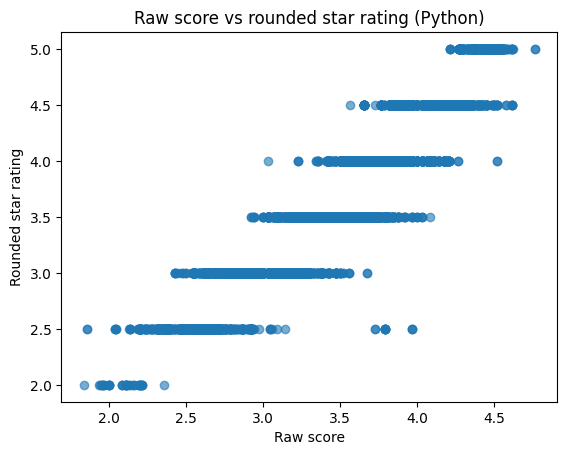

In [16]:
# Plot the data for relationship 
question_4 = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015], ignore_index=True)
question_4["Star_Rating"] = pd.to_numeric(question_4["Star_Rating"], errors="coerce")

# 1) One row per plan-year
plan_year_4 = (
    question_4.groupby(["year", "contractid", "planid"], as_index=False)
     .agg(
         star_rating=("Star_Rating", "first"),
         enrollments=("avg_enrollment", "first"),
         raw_rating=("raw_rating", "first")
     )
     .dropna(subset=["enrollments"])
)


plan_year_4["market_share"] = (
    plan_year_4["enrollments"] /
    plan_year_4.groupby("year")["enrollments"].transform("sum")
)

# Python scatterplot
fig, ax = plt.subplots()
ax.scatter(plan_year_4["raw_rating"], plan_year_4["star_rating"], alpha=0.6)
ax.set_xlabel("Raw score")
ax.set_ylabel("Rounded star rating")
ax.set_title("Raw score vs rounded star rating (Python)")
plt.show()

In [17]:
q2014 = question_4[question_4["year"] == 2014].copy()

print("2014 rows:", len(q2014))
print("Star_Rating missing share:", q2014["Star_Rating"].isna().mean())
print("Sample raw Star_Rating values (before numeric coercion):")
print(data_2014["Star_Rating"].head(20) if "Star_Rating" in data_2014.columns else "No Star_Rating col in data_2014")

# If you still have the pre-coercion values, also do:
# print(data_2014["Star_Rating"].astype(str).value_counts().head(20))

2014 rows: 60497
Star_Rating missing share: 0.053688612658478935
Sample raw Star_Rating values (before numeric coercion):
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: Star_Rating, dtype: float64


In [18]:
# 3.1 OLS on full sample
ols_py = smf.ols("market_share ~ star_rating", data=plan_year_4).fit()
print(ols_py.summary())

                            OLS Regression Results                            
Dep. Variable:           market_share   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.121
Date:                Mon, 02 Mar 2026   Prob (F-statistic):             0.0424
Time:                        13:12:27   Log-Likelihood:                 48031.
No. Observations:                9787   AIC:                        -9.606e+04
Df Residuals:                    9785   BIC:                        -9.604e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.0004      0.000      3.638      

In [19]:
question_4 = plan_year_4.copy()

# keep the columns we need and drop missing
question_4 = question_4.dropna(subset=["year", "market_share", "star_rating"])

# Create categorical rating group:
# base: <=2.5
# indicators: 3, 3.5, 4, >=4.5
def rating_group(x):
    if pd.isna(x):
        return np.nan
    if x <= 2.5:
        return "<=2.5"
    elif x == 3.0:
        return "3"
    elif x == 3.5:
        return "3.5"
    elif x == 4.0:
        return "4"
    elif x >= 4.5:
        return ">=4.5"
    else:
        # If your data has weird values (like 4.33), you can decide how to handle them
        # For now: treat anything between 4.0 and 4.5 as "4"
        return "4"

question_4["rating_grp"] = question_4["star_rating"].apply(rating_group)

# Make it an ordered categorical so the reference category is well-defined
cat_order = ["<=2.5", "3", "3.5", "4", ">=4.5"]
question_4["rating_grp"] = pd.Categorical(question_4["rating_grp"], categories=cat_order, ordered=True)

In [20]:
# 3.1 OLS on full sample
# question_4_include = question_4[question_4["star_rating"] > 2.5].copy()
ols_data_2010 = question_4[question_4["year"] == 2010]
ols_data_2011 = question_4[question_4["year"] == 2011]
ols_data_2012 = question_4[question_4["year"] == 2012]
ols_data_2013 = question_4[question_4["year"] == 2013]
ols_data_2014 = question_4[question_4["year"] == 2014]
ols_data_2015 = question_4[question_4["year"] == 2015]

ols_2010 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2010).fit()
ols_2011 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2011).fit()
ols_2012 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2012).fit()
ols_2013 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2013).fit()
ols_2014 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2014).fit()
ols_2015 = smf.ols("market_share ~ C(rating_grp, Treatment(reference='<=2.5'))", data=ols_data_2015).fit()

In [21]:
# Plot results 
results = {
    "2010": ols_2010,
    "2011": ols_2011,
    "2012": ols_2012,
    "2013": ols_2013,
    "2014": ols_2014,
    "2015": ols_2015,
}

rows = ["Intercept", "Star=3", "Star=3.5", "Star=4", "Star>=4.5", "N", "R2"]
table = pd.DataFrame(index=rows, columns=results.keys())

p3   = "C(rating_grp, Treatment(reference='<=2.5'))[T.3]"
p35  = "C(rating_grp, Treatment(reference='<=2.5'))[T.3.5]"
p4   = "C(rating_grp, Treatment(reference='<=2.5'))[T.4]"
p45  = "C(rating_grp, Treatment(reference='<=2.5'))[T.>=4.5]"

for year, model in results.items():
    table.loc["Intercept", year] = f"{model.params.get('Intercept', float('nan')):.4f}"
    table.loc["Star=3", year]    = f"{model.params.get(p3,  float('nan')):.4f}"
    table.loc["Star=3.5", year]  = f"{model.params.get(p35, float('nan')):.4f}"
    table.loc["Star=4", year]    = f"{model.params.get(p4,  float('nan')):.4f}"
    table.loc["Star>=4.5", year] = f"{model.params.get(p45, float('nan')):.4f}"
    table.loc["N", year] = int(model.nobs)
    table.loc["R2", year] = f"{model.rsquared:.4f}"

table

,2010,2011,2012,2013,2014,2015
Intercept,0.0005,0.0004,0.0002,0.0002,0.0001,0.0001
Star=3,0.0001,0.0002,0.0002,0.0003,0.0003,0.0003
Star=3.5,0.0001,0.0005,0.0006,0.0004,0.0004,0.0004
Star=4,0.0003,0.0003,0.0006,0.0006,0.0006,0.0005
Star>=4.5,-0.0002,0.0001,0.0002,0.0003,0.0004,0.0003
N,1489,1455,1625,1808,1742,1668
R2,0.0054,0.0063,0.0127,0.0080,0.0057,0.0041


## Question 5

In [22]:
question_5 = question_4[question_4["year"] == 2010].copy()

# Keep only the star ratings requested: 3, 3.5, 4, 4.5, 5
keep = [3.0, 3.5, 4.0, 4.5, 5.0]
question_5 = question_5[question_5["star_rating"].isin(keep)].copy()

# Rounded up indicator
question_5["rounded_up"] = (question_5["raw_rating"] < question_5["star_rating"]).astype(int)

# Table: number of plans rounded up INTO each star rating
question5_table = (
    question_5.groupby("star_rating", as_index=False)
           .agg(plans_rounded_up=("rounded_up", "sum"),
                total_plans=("rounded_up", "size"))
           .sort_values("star_rating")
)

question5_table
table = (
    question_5
    .assign(flag=lambda df: df["raw_rating"] < df["star_rating"])
    .groupby("star_rating")["flag"]
    .sum()
    .rename("plans_rounded_up")
    .reset_index()
)

table

,star_rating,plans_rounded_up
0,3.0,165
1,3.5,177
2,4.0,209
3,4.5,156
4,5.0,8


## Question 6

In [23]:
# Candidates: partc_score 2.5 or 3 with non-missing raw_rating and star_rating
question_6 = plan_year_4[plan_year_4["year"] == 2010].copy()

candidates_mask = (
    question_6["raw_rating"].notna()
    & question_6["star_rating"].isin([2.5, 3.0])
)
ma_25star_candidates = question_6.loc[candidates_mask].copy()

n_candidates_total = len(ma_25star_candidates)

# Final sample: raw_rating in the range consistent with the star score
match_mask = (
    ma_25star_candidates["raw_rating"].between(2.5, 3)
    & (
        ((ma_25star_candidates["star_rating"] == 3.0) &
         (ma_25star_candidates["raw_rating"] >= 2.75))
        |
        ((ma_25star_candidates["star_rating"] == 2.5) &
         (ma_25star_candidates["raw_rating"] < 2.75))
    )
)
ma_25star_py = ma_25star_candidates.loc[match_mask].copy()

n_25star_total_py = len(ma_25star_py)

print("Obs with partc_score 2.5 or 3:", n_candidates_total)
print("Obs with raw_rating in the matching range:", n_25star_total_py)


Obs with partc_score 2.5 or 3: 758
Obs with raw_rating in the matching range: 354


Mass points detected in the running variable.


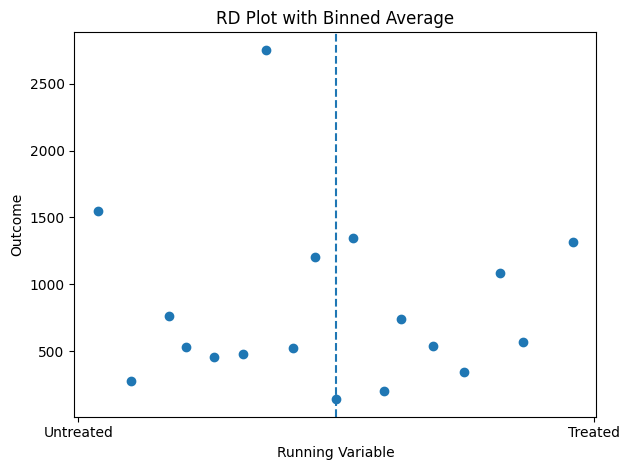

In [24]:
import matplotlib.pyplot as plt

if rd_available:
    rd_result = rdplot(
        y=ma_25star_py["enrollments"].values,
        x=ma_25star_py["raw_rating"].values,
        c=2.75,
        p=2,
        title="RD Plot with Binned Average",
        x_label="Running Variable",
        y_label="Outcome",
        hide=True
    )

    bin_avg = rd_result.vars_bins

    fig, ax = plt.subplots()
    ax.scatter(bin_avg["rdplot_mean_x"], bin_avg["rdplot_mean_y"])
    ax.axvline(x=2.75, linestyle="--")
    ax.set_xticks([2.5, 3.0])
    ax.set_xticklabels(["Untreated", "Treated"])
    ax.set_xlabel("Running Variable")
    ax.set_ylabel("Outcome")
    ax.set_title("RD Plot with Binned Average")
    plt.tight_layout()
    plt.show()
else:
    print("rdrobust not available in Python; use the R code above for the RD plot.")


In [25]:
import statsmodels.formula.api as smf

ma_rd1 = ma_25star_py.copy()
ma_rd1["score"] = ma_rd1["raw_rating"] - 2.75
ma_rd1["treat"] = (ma_rd1["score"] >= 0).astype(int)
ma_rd1["window1"] = ma_rd1["score"].between(-0.175, 0.175)
ma_rd1["window2"] = ma_rd1["score"].between(-0.125, 0.125)
ma_rd1["score_treat"] = ma_rd1["score"] * ma_rd1["treat"]

star25_1 = smf.ols("enrollments ~ score + treat", data=ma_rd1).fit()
star25_2 = smf.ols("enrollments ~ score + treat", data=ma_rd1[ma_rd1["window1"]]).fit()
star25_3 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1[ma_rd1["window1"]]).fit()
star25_4 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1[ma_rd1["window2"]]).fit()

est1_py = float(star25_1.params["treat"])
est2_py = float(star25_2.params["treat"])
est3_py = float(star25_3.params["treat"])
est4_py = float(star25_4.params["treat"])

print(star25_1.summary().tables[1])
print(star25_2.summary().tables[1])
print(star25_3.summary().tables[1])
print(star25_4.summary().tables[1])


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1202.8962    435.687      2.761      0.006     346.012    2059.781
score       2338.4980   2694.155      0.868      0.386   -2960.218    7637.215
treat       -716.6149    817.219     -0.877      0.381   -2323.877     890.647
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1198.0315    476.105      2.516      0.013     260.094    2135.969
score       3275.6355   4205.926      0.779      0.437   -5010.141    1.16e+04
treat       -918.4635    897.384     -1.023      0.307   -2686.331     849.405
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    1435.4481    648.620      2.213      

In [26]:
if rd_available:
    est1_py = rdrobust(
        y=ma_rd1["enrollments"].values,
        x=ma_rd1["score"].values,
        c=0,
        h=0.125,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

    estopt_py = rdrobust(
        y=ma_rd1["enrollments"].values,
        x=ma_rd1["score"].values,
        c=0,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )
    print("Fixed bandwidth estimate:")
    print(est1_py)
    print("\nOptimal bandwidth estimate:")
    print(estopt_py)
else:
    print("rdrobust not available in Python; use the R code above for RD estimation.")


Fixed bandwidth estimate:
Call: rdrobust
Number of Observations:                   354
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                        HC0

                                Left      Right
------------------------------------------------
Number of Observations           167        187
Number of Unique Obs.            167        187
Number of Effective Obs.          87         79
Bandwidth Estimation           0.125      0.125
Bandwidth Bias                 0.125      0.125
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional    -932.448   866.86   -1.076   2.821e-01 [-2631.463, 766.567]
Robust                 -        -    0.266   7.900e-01 [-3044.556, 4002.231

In [27]:
# Candidates: partc_score 2.5 or 3 with non-missing raw_rating and star_rating
question_6 = plan_year_4[plan_year_4["year"] == 2010].copy()

candidates_mask_2 = (
    question_6["raw_rating"].notna()
    & question_6["star_rating"].isin([3.0, 3.5])
)
ma_25star_candidates_2 = question_6.loc[candidates_mask_2].copy()

n_candidates_total_2 = len(ma_25star_candidates_2)

# Final sample: raw_rating in the range consistent with the star score
match_mask_2 = (
    ma_25star_candidates_2["raw_rating"].between(3.0, 3.5)
    & (
        ((ma_25star_candidates_2["star_rating"] == 3.5) &
         (ma_25star_candidates_2["raw_rating"] >= 3.25))
        |
        ((ma_25star_candidates_2["star_rating"] == 3.0) &
         (ma_25star_candidates_2["raw_rating"] < 3.25))
    )
)
ma_25star_py_2 = ma_25star_candidates_2.loc[match_mask_2].copy()

n_25star_total_py_2 = len(ma_25star_py_2)

print("Obs with partc_score 3.0 or 3.5:", n_candidates_total_2)
print("Obs with raw_rating in the matching range:", n_25star_total_py_2)


Obs with partc_score 3.0 or 3.5: 759
Obs with raw_rating in the matching range: 481


Mass points detected in the running variable.


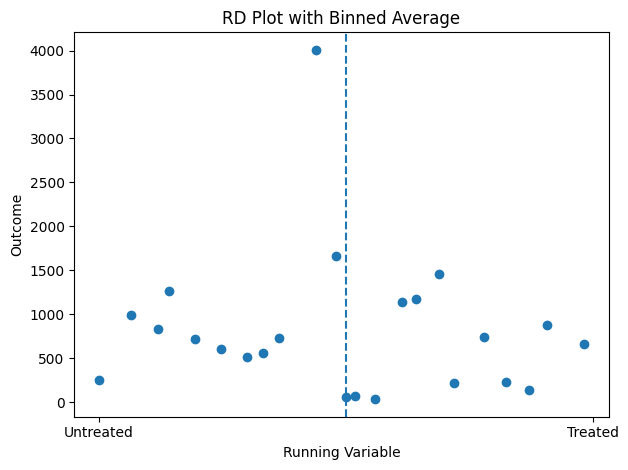

In [28]:
import matplotlib.pyplot as plt

if rd_available:
    rd_result = rdplot(
        y=ma_25star_py_2["enrollments"].values,
        x=ma_25star_py_2["raw_rating"].values,
        c=3.25,
        p=2,
        title="RD Plot with Binned Average",
        x_label="Running Variable",
        y_label="Outcome",
        hide=True
    )

    bin_avg = rd_result.vars_bins

    fig, ax = plt.subplots()
    ax.scatter(bin_avg["rdplot_mean_x"], bin_avg["rdplot_mean_y"])
    ax.axvline(x=3.25, linestyle="--")
    ax.set_xticks([3.0, 3.5])
    ax.set_xticklabels(["Untreated", "Treated"])
    ax.set_xlabel("Running Variable")
    ax.set_ylabel("Outcome")
    ax.set_title("RD Plot with Binned Average")
    plt.tight_layout()
    plt.show()
else:
    print("rdrobust not available in Python; use the R code above for the RD plot.")


In [29]:
ma_rd1_2 = ma_25star_py_2.copy()
ma_rd1_2["score"] = ma_rd1_2["raw_rating"] - 3.25
ma_rd1_2["treat"] = (ma_rd1_2["score"] >= 0).astype(int)
ma_rd1_2["window1"] = ma_rd1_2["score"].between(-0.175, 0.175)
ma_rd1_2["window2"] = ma_rd1_2["score"].between(-0.125, 0.125)
ma_rd1_2["score_treat"] = ma_rd1_2["score"] * ma_rd1_2["treat"]

star25_1_2 = smf.ols("enrollments ~ score + treat", data=ma_rd1_2).fit()
star25_2_2 = smf.ols("enrollments ~ score + treat", data=ma_rd1_2[ma_rd1_2["window1"]]).fit()
star25_3_2 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1_2[ma_rd1_2["window1"]]).fit()
star25_4_2 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1_2[ma_rd1_2["window2"]]).fit()

est1_py_2 = float(star25_1_2.params["treat"])
est2_py_2 = float(star25_2_2.params["treat"])
est3_py_2 = float(star25_3_2.params["treat"])
est4_py_2 = float(star25_4_2.params["treat"])

print(star25_1_2.summary().tables[1])
print(star25_2_2.summary().tables[1])
print(star25_3_2.summary().tables[1])
print(star25_4_2.summary().tables[1])


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    923.1579    182.576      5.056      0.000     564.407    1281.909
score       1355.5903   1199.217      1.130      0.259   -1000.799    3711.980
treat       -471.7388    350.909     -1.344      0.179   -1161.254     217.776
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1146.2108    273.586      4.190      0.000     608.143    1684.279
score       3871.1043   2455.133      1.577      0.116    -957.470    8699.678
treat       -870.4722    518.765     -1.678      0.094   -1890.740     149.796
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    1543.2242    356.049      4.334      

In [30]:
if rd_available:
    est1_py_2 = rdrobust(
        y=ma_rd1_2["enrollments"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        h=0.125,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

    estopt_py_2 = rdrobust(
        y=ma_rd1_2["enrollments"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )
    print("Fixed bandwidth estimate:")
    print(est1_py_2)
    print("\nOptimal bandwidth estimate:")
    print(estopt_py_2)
else:
    print("rdrobust not available in Python; use the R code above for RD estimation.")


Fixed bandwidth estimate:
Call: rdrobust
Number of Observations:                   481
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                        HC0

                                Left      Right
------------------------------------------------
Number of Observations           282        199
Number of Unique Obs.            282        199
Number of Effective Obs.         173        105
Bandwidth Estimation           0.125      0.125
Bandwidth Bias                 0.125      0.125
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional    -1332.666   747.92   -1.782   7.478e-02 [-2798.563, 133.23]
Robust                 -        -   -2.556   1.058e-02 [-5078.499, -670.675

In [31]:
float(est1_py.coef.iloc[0])
float(est1_py_2.coef.iloc[0])

/tmp/ipykernel_1185412/3733012864.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
/tmp/ipykernel_1185412/3733012864.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


-1332.6664422056047

In [32]:
import pandas as pd
import numpy as np

def rd_row(label, est, h=0.125):
    return {
        "Cutoff comparison": label,
        "Bandwidth (h)": h,
        "Estimate (Δ enrollments)": float(est.coef.iloc[0, 0]),
        "SE": float(est.se.iloc[0, 0]),
        "p-value": float(est.pv.iloc[0, 0]) if isinstance(est.pv, pd.DataFrame) else float(np.asarray(est.pv).reshape(-1)[0]),
        "95% CI (low)": float(est.ci.iloc[0, 0]),
        "95% CI (high)": float(est.ci.iloc[0, 1]),
    }

results = pd.DataFrame([
    rd_row("3.0 vs 2.5 (cutoff at 2.75)", est1_py, h=0.125),
    rd_row("3.5 vs 3.0 (cutoff at 3.25)", est1_py_2, h=0.125),
])

results_q6 = results.copy()
results_q6

,Cutoff comparison,Bandwidth (h),Estimate (Δ enrollments),SE,p-value,95% CI (low),95% CI (high)
0,3.0 vs 2.5 (cutoff at 2.75),0.125,-932.447879,866.860316,0.282079,-2631.462877,766.567120
1,3.5 vs 3.0 (cutoff at 3.25),0.125,-1332.666442,747.920038,0.074777,-2798.562780,133.229896


## Question 7 

In [33]:
# 3.0 stars
question_6 = plan_year_4[plan_year_4["year"] == 2010].copy()

candidates_mask = (
    question_6["raw_rating"].notna()
    & question_6["star_rating"].isin([2.5, 3.0])
)
ma_25star_candidates = question_6.loc[candidates_mask].copy()

n_candidates_total = len(ma_25star_candidates)

# Final sample: raw_rating in the range consistent with the star score
match_mask = (
    ma_25star_candidates["raw_rating"].between(2.5, 3)
    & (
        ((ma_25star_candidates["star_rating"] == 3.0) &
         (ma_25star_candidates["raw_rating"] >= 2.75))
        |
        ((ma_25star_candidates["star_rating"] == 2.5) &
         (ma_25star_candidates["raw_rating"] < 2.75))
    )
)
ma_25star_py = ma_25star_candidates.loc[match_mask].copy()

n_25star_total_py = len(ma_25star_py)

print("Obs with partc_score 2.5 or 3:", n_candidates_total)
print("Obs with raw_rating in the matching range:", n_25star_total_py)


Obs with partc_score 2.5 or 3: 758
Obs with raw_rating in the matching range: 354


In [34]:
# 3.0 and 3.5 
if rd_available:
    est1_py_2_01 = rdrobust(
        y=ma_rd1_2["enrollments"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        h=0.1,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

    # estopt_py_2 = rdrobust(
    #     y=ma_rd1_2["enrollments"].values,
    #     x=ma_rd1_2["score"].values,
    #     c=0,
    #     p=1,
    #     kernel="uniform",
    #     vce="hc0",
    #     masspoints="off",
    
    print("Fixed bandwidth estimate:")
    print(est1_py_2_01)
    # print("\nOptimal bandwidth estimate:")
    # print(estopt_py_2)


Fixed bandwidth estimate:
Call: rdrobust
Number of Observations:                   481
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                        HC0

                                Left      Right
------------------------------------------------
Number of Observations           282        199
Number of Unique Obs.            282        199
Number of Effective Obs.         115         65
Bandwidth Estimation             0.1        0.1
Bandwidth Bias                   0.1        0.1
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional    -2322.331  899.437   -2.582   9.823e-03 [-4085.194, -559.468]
Robust                 -        -   -2.199   2.786e-02 [-4965.487, -285.6

In [35]:
# 3.0 and 3.5 
if rd_available:
    est1_py_2_012 = rdrobust(
        y=ma_rd1_2["enrollments"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        h=0.12,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

    # estopt_py_2 = rdrobust(
    #     y=ma_rd1_2["enrollments"].values,
    #     x=ma_rd1_2["score"].values,
    #     c=0,
    #     p=1,
    #     kernel="uniform",
    #     vce="hc0",
    #     masspoints="off",
    
    print("Fixed bandwidth estimate:")
    print(est1_py_2_012)
    # print("\nOptimal bandwidth estimate:")
    # print(estopt_py_2)


Fixed bandwidth estimate:
Call: rdrobust
Number of Observations:                   481
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                        HC0

                                Left      Right
------------------------------------------------
Number of Observations           282        199
Number of Unique Obs.            282        199
Number of Effective Obs.         139         95
Bandwidth Estimation            0.12       0.12
Bandwidth Bias                  0.12       0.12
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional    -1745.54  827.969   -2.108   3.501e-02 [-3368.329, -122.751]
Robust                 -        -   -2.411   1.591e-02 [-5089.954, -525.26

In [36]:
# 3.0 and 3.5 
if rd_available:
    est1_py_2_013 = rdrobust(
        y=ma_rd1_2["enrollments"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        h=0.13,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

    print("Fixed bandwidth estimate:")
    print(est1_py_2_013)
    # print("\nOptimal bandwidth estimate:")
    # print(estopt_py_2)


Fixed bandwidth estimate:
Call: rdrobust
Number of Observations:                   481
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                        HC0

                                Left      Right
------------------------------------------------
Number of Observations           282        199
Number of Unique Obs.            282        199
Number of Effective Obs.         182        105
Bandwidth Estimation            0.13       0.13
Bandwidth Bias                  0.13       0.13
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional    -1327.813  728.036   -1.824   6.818e-02 [-2754.737, 99.111]
Robust                 -        -   -2.545   1.093e-02 [-5030.254, -653.126

In [37]:
# 3.0 and 3.5 
if rd_available:
    est1_py_2_014 = rdrobust(
        y=ma_rd1_2["enrollments"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        h=0.14,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

    print("Fixed bandwidth estimate:")
    print(est1_py_2_014)

Fixed bandwidth estimate:
Call: rdrobust
Number of Observations:                   481
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                        HC0

                                Left      Right
------------------------------------------------
Number of Observations           282        199
Number of Unique Obs.            282        199
Number of Effective Obs.         193        115
Bandwidth Estimation            0.14       0.14
Bandwidth Bias                  0.14       0.14
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional    -1376.509  719.023   -1.914   5.557e-02 [-2785.768, 32.75]
Robust                 -        -   -2.309   2.097e-02 [-4699.322, -383.756]

In [38]:
# 3.0 and 3.5 
if rd_available:
    est1_py_2_015 = rdrobust(
        y=ma_rd1_2["enrollments"].values,
        x=ma_rd1_2["score"].values,
        c=0,
        h=0.15,
        p=1,
        kernel="uniform",
        vce="hc0",
        masspoints="off",
    )

    print("Fixed bandwidth estimate:")
    print(est1_py_2_015)

Fixed bandwidth estimate:
Call: rdrobust
Number of Observations:                   481
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                        HC0

                                Left      Right
------------------------------------------------
Number of Observations           282        199
Number of Unique Obs.            282        199
Number of Effective Obs.         196        126
Bandwidth Estimation            0.15       0.15
Bandwidth Bias                  0.15       0.15
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional    -1248.542  710.857   -1.756   7.902e-02 [-2641.797, 144.713]
Robust                 -        -   -2.343   1.912e-02 [-4680.244, -416.84

In [39]:
def rd_row(label, est, h):
    return {
        "Cutoff": label,
        "Bandwidth (h)": h,
        "Estimate": float(est.coef.iloc[0, 0]),
        "Std. Error": float(est.se.iloc[0, 0]),
        "p-value": float(est.pv.iloc[0, 0]),
        "CI Lower": float(est.ci.iloc[0, 0]),
        "CI Upper": float(est.ci.iloc[0, 1]),
    }

results = pd.DataFrame([
    rd_row("3.5 vs 3.0", est1_py_2, 0.125),
    rd_row("3.5 vs 3.0", est1_py_2_015, 0.15),
])

results

,Cutoff,Bandwidth (h),Estimate,Std. Error,p-value,CI Lower,CI Upper
0,3.5 vs 3.0,0.125,-1332.666442,747.920038,0.074777,-2798.56278,133.229896
1,3.5 vs 3.0,0.150,-1248.542154,710.857422,0.079022,-2641.79710,144.712792


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdrobust import rdrobust

bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]

def run_rd_for_bandwidths(df, label, bandwidths):
    rows = []
    for h in bandwidths:
        est = rdrobust(
            y=df["enrollments"].values,
            x=df["score"].values,
            c=0,
            h=h,
            p=1,
            kernel="uniform",
            vce="hc0",
            masspoints="off",
        )

        # Your rdrobust object fields are DataFrames, so use .iloc
        rows.append({
            "cutoff": label,
            "h": h,
            "estimate": float(est.coef.iloc[0, 0]),
            "se": float(est.se.iloc[0, 0]),
            "ci_low": float(est.ci.iloc[0, 0]),
            "ci_high": float(est.ci.iloc[0, 1]),
            "p_value": float(est.pv.iloc[0, 0]),
        })
    return pd.DataFrame(rows)

res_3  = run_rd_for_bandwidths(ma_rd1.dropna(subset=["enrollments","score"]),
                               "3.0 vs 2.5 (cutoff=2.75)", bandwidths)
res_35 = run_rd_for_bandwidths(ma_rd1_2.dropna(subset=["enrollments","score"]),
                               "3.5 vs 3.0 (cutoff=3.25)", bandwidths)

results = pd.concat([res_3, res_35], ignore_index=True)
results

,cutoff,h,estimate,se,ci_low,ci_high,p_value
0,3.0 vs 2.5 (cutoff=2.75),0.10,-432.331446,772.975036,-1947.334678,1082.671787,0.575951
1,3.0 vs 2.5 (cutoff=2.75),0.12,-889.688008,821.271919,-2499.351391,719.975376,0.278673
2,3.0 vs 2.5 (cutoff=2.75),0.13,-820.783267,885.227187,-2555.796672,914.230139,0.353822
3,3.0 vs 2.5 (cutoff=2.75),0.14,-843.979778,892.842866,-2593.919639,905.960083,0.344520
4,3.0 vs 2.5 (cutoff=2.75),0.15,-772.471310,897.897708,-2532.318480,987.375859,0.389618
5,3.5 vs 3.0 (cutoff=3.25),0.10,-2322.331072,899.436569,-4085.194354,-559.467789,0.009823
6,3.5 vs 3.0 (cutoff=3.25),0.12,-1745.539862,827.968908,-3368.329102,-122.750622,0.035012
7,3.5 vs 3.0 (cutoff=3.25),0.13,-1327.813026,728.035927,-2754.737222,99.111171,0.068178
8,3.5 vs 3.0 (cutoff=3.25),0.14,-1376.508980,719.022954,-2785.768073,32.750114,0.055567
9,3.5 vs 3.0 (cutoff=3.25),0.15,-1248.542154,710.857422,-2641.797100,144.712792,0.079022


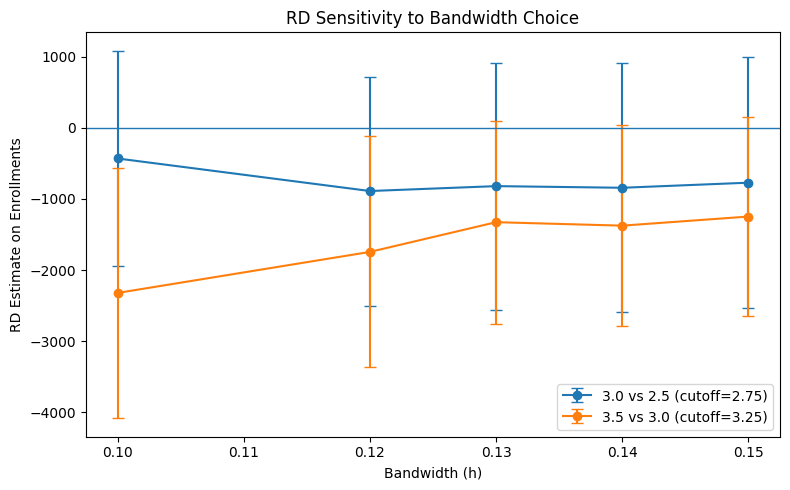

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for cutoff, g in results.groupby("cutoff"):
    g = g.sort_values("h")
    yerr = np.vstack([g["estimate"] - g["ci_low"], g["ci_high"] - g["estimate"]])
    plt.errorbar(g["h"], g["estimate"], yerr=yerr, marker="o", capsize=4, label=cutoff)

plt.axhline(0, linewidth=1)
plt.xlabel("Bandwidth (h)")
plt.ylabel("RD Estimate on Enrollments")
plt.title("RD Sensitivity to Bandwidth Choice")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# The results for 3.0 versus 2.5 are not statistically significant at any bandwith. However, the estimate for 3.5 vs 3.0 increases with increasing bandwidth and is significant.

## Question 8

Mass points detected in the running variable.


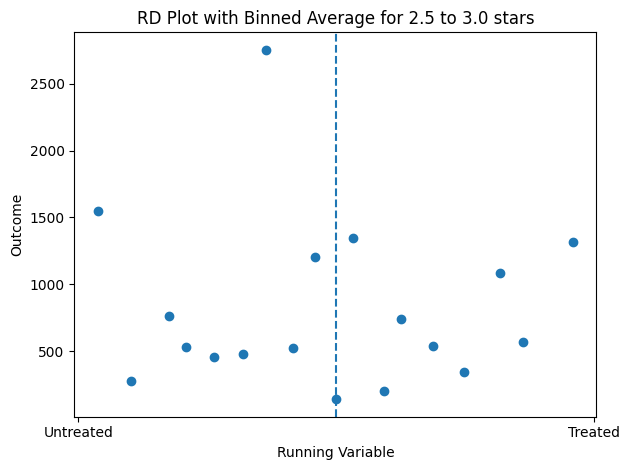

In [56]:
if rd_available:
    rd_result = rdplot(
        y=ma_25star_py["enrollments"].values,
        x=ma_25star_py["raw_rating"].values,
        c=2.75,
        p=2,
        title="RD Plot with Binned Average",
        x_label="Running Variable",
        y_label="Outcome",
        hide=True
    )

    bin_avg = rd_result.vars_bins

    fig, ax = plt.subplots()
    ax.scatter(bin_avg["rdplot_mean_x"], bin_avg["rdplot_mean_y"])
    ax.axvline(x=2.75, linestyle="--")
    ax.set_xticks([2.5, 3.0])
    ax.set_xticklabels(["Untreated", "Treated"])
    ax.set_xlabel("Running Variable")
    ax.set_ylabel("Outcome")
    ax.set_title("RD Plot with Binned Average for 2.5 to 3.0 stars")
    plt.tight_layout()
    plt.show()
else:
    print("rdrobust not available in Python; use the R code above for the RD plot.")


Mass points detected in the running variable.


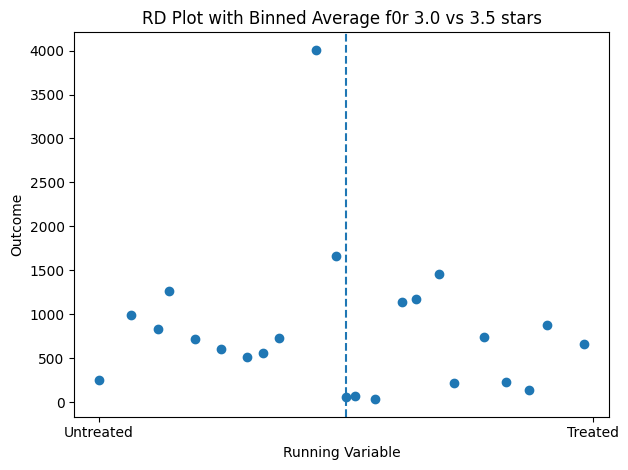

In [57]:
if rd_available:
    rd_result = rdplot(
        y=ma_25star_py_2["enrollments"].values,
        x=ma_25star_py_2["raw_rating"].values,
        c=3.25,
        p=2,
        title="RD Plot with Binned Average",
        x_label="Running Variable",
        y_label="Outcome",
        hide=True
    )

    bin_avg = rd_result.vars_bins

    fig, ax = plt.subplots()
    ax.scatter(bin_avg["rdplot_mean_x"], bin_avg["rdplot_mean_y"])
    ax.axvline(x=3.25, linestyle="--")
    ax.set_xticks([3.0, 3.5])
    ax.set_xticklabels(["Untreated", "Treated"])
    ax.set_xlabel("Running Variable")
    ax.set_ylabel("Outcome")
    ax.set_title("RD Plot with Binned Average f0r 3.0 vs 3.5 stars")
    plt.tight_layout()
    plt.show()
else:
    print("rdrobust not available in Python; use the R code above for the RD plot.")


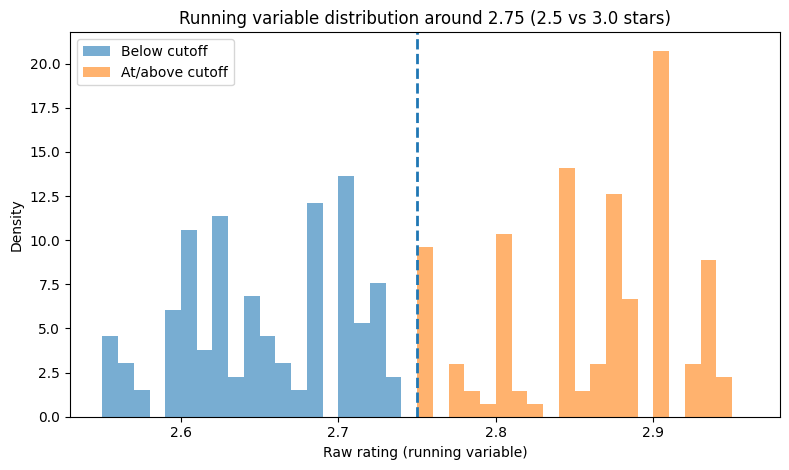

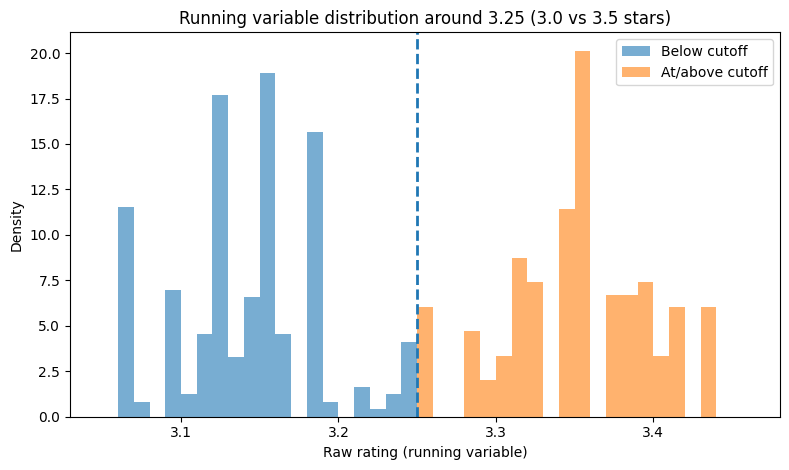

In [44]:
def plot_running_distribution(df, cutoff, window=0.20, binwidth=0.01, title=""):
    """
    Graphical manipulation check:
    histogram of the RUNNING VARIABLE around the cutoff.
    """
    x = df["raw_rating"].dropna().to_numpy()
    x = x[(x >= cutoff - window) & (x <= cutoff + window)]

    bins = np.arange(cutoff - window, cutoff + window + binwidth, binwidth)

    plt.figure(figsize=(8, 4.8))
    plt.hist(x[x < cutoff],  bins=bins, density=True, alpha=0.6, label="Below cutoff")
    plt.hist(x[x >= cutoff], bins=bins, density=True, alpha=0.6, label="At/above cutoff")
    plt.axvline(cutoff, linestyle="--", linewidth=2)

    plt.xlabel("Raw rating (running variable)")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_running_distribution(
    ma_25star_candidates, cutoff=2.75, window=0.20, binwidth=0.01,
    title="Running variable distribution around 2.75 (2.5 vs 3.0 stars)"
)

plot_running_distribution(
    ma_25star_candidates_2, cutoff=3.25, window=0.20, binwidth=0.01,
    title="Running variable distribution around 3.25 (3.0 vs 3.5 stars)"
)

In [58]:
# There is not much of a difference for the untreated versus treated groups for the threshold values.

## Question 9 

In [59]:
for c in data_2010.columns:
    print(c)

contractid
planid
fips
year_x
n_nonmiss
avg_enrollment
first_enrollment
last_enrollment
state
county
org_type
plan_type
partd
snp
eghp
org_name
org_marketing_name
plan_name
parent_org
contract_date
state_long
county_long
year_pen
n_elig
n_enrol
avg_eligibles
first_eligibles
last_eligibles
avg_enrolled
sd_enrolled
min_enrolled
max_enrolled
first_enrolled
last_enrolled
ssa
state_name
state_land
premium
premium_partc
premium_partd_basic
premium_partd_supp
premium_partd_total
partd_deductible
year_land
riskscore_partc
payment_partc
rebate_partc
year_y
payment_partd
directsubsidy_partd
reinsurance_partd
costsharing_partd
riskscore_partd
basic_premium
bid
breastcancer_screen
rectalcancer_screen
cv_diab_cholscreen
glaucoma_test
monitoring
flu_vaccine
pn_vaccine
physical_health
mental_health
osteo_test
physical_monitor
primaryaccess
osteo_manage
diab_healthy
bloodpressure
ra_manage
copd_test
bladder
falling
nodelays
doctor_communicate
carequickly
customer_service
overallrating_care
overallrati

In [60]:
data_2010["plan_type"].unique()

array(['Local PPO', 'National PACE', 'HMO/HMOPOS',
       'Continuing Care Retirement Community', '1876 Cost', 'PFFS',
       'ESRD I', 'PSO (State License)', 'MSA', 'Regional PPO'],
      dtype=object)

In [61]:
data_2010["partd"].unique()

array(['Yes', 'No'], dtype=object)

In [62]:
plan_year_9 = (
    data_2010.groupby(["year", "contractid", "planid"], as_index=False)
     .agg(
         star_rating=("Star_Rating", "first"),
         enrollments=("avg_enrollment", "first"),
         raw_rating=("raw_rating", "first"),
         plan_type=("plan_type", "first"),
         partd=("partd","first")
     )
     .dropna(subset=["enrollments"])
)


plan_year_9["market_share"] = (
    plan_year_9["enrollments"] /
    plan_year_9.groupby("year")["enrollments"].transform("sum")
)

plan_year_9

,year,contractid,planid,star_rating,enrollments,raw_rating,plan_type,partd,market_share
0,2010,H0084,1,NaN,34.666667,NaN,Local PPO,Yes,0.000028
1,2010,H0104,2,3.0,54.900000,3.107143,Local PPO,Yes,0.000044
2,2010,H0104,4,3.0,226.400000,3.107143,Local PPO,Yes,0.000180
3,2010,H0104,8,3.0,140.100000,3.107143,Local PPO,Yes,0.000112
4,2010,H0105,1,NaN,49.800000,NaN,National PACE,Yes,0.000040
...,...,...,...,...,...,...,...,...,...
2522,2010,R7444,1,NaN,1346.900000,NaN,Regional PPO,Yes,0.001074
2523,2010,R9896,12,2.5,15.333333,2.730769,Regional PPO,Yes,0.000012
2524,2010,R9943,1,2.0,2139.900000,2.080000,Regional PPO,Yes,0.001706
2525,2010,R9943,3,2.0,241.500000,2.080000,Regional PPO,Yes,0.000193


In [63]:
plan_year_9["hmo_status"] = (plan_year_9["plan_type"] == "HMO/HMOPOS").astype(int)

In [64]:
plan_year_9["partd_status"] = (plan_year_9["partd"] == "Yes").astype(int)

In [65]:
plan_year_9

,year,contractid,planid,star_rating,enrollments,...,plan_type,partd,market_share,hmo_status,partd_status
0,2010,H0084,1,NaN,34.666667,...,Local PPO,Yes,0.000028,0,1
1,2010,H0104,2,3.0,54.900000,...,Local PPO,Yes,0.000044,0,1
2,2010,H0104,4,3.0,226.400000,...,Local PPO,Yes,0.000180,0,1
3,2010,H0104,8,3.0,140.100000,...,Local PPO,Yes,0.000112,0,1
4,2010,H0105,1,NaN,49.800000,...,National PACE,Yes,0.000040,0,1
...,...,...,...,...,...,...,...,...,...,...,...
2522,2010,R7444,1,NaN,1346.900000,...,Regional PPO,Yes,0.001074,0,1
2523,2010,R9896,12,2.5,15.333333,...,Regional PPO,Yes,0.000012,0,1
2524,2010,R9943,1,2.0,2139.900000,...,Regional PPO,Yes,0.001706,0,1
2525,2010,R9943,3,2.0,241.500000,...,Regional PPO,Yes,0.000193,0,1


In [66]:
# Candidates: partc_score 2.5 or 3 with non-missing raw_rating and star_rating
candidates_mask_9 = (
    plan_year_9["raw_rating"].notna()
    & plan_year_9["star_rating"].isin([2.5, 3.0])
)
ma_25star_candidates_9 = plan_year_9.loc[candidates_mask_9].copy()

n_candidates_total_9 = len(ma_25star_candidates_9)

# Final sample: raw_rating in the range consistent with the star score
match_mask_9 = (
    ma_25star_candidates_9["raw_rating"].between(2.5, 3)
    & (
        ((ma_25star_candidates_9["star_rating"] == 3.0) &
         (ma_25star_candidates_9["raw_rating"] >= 2.75))
        |
        ((ma_25star_candidates_9["star_rating"] == 2.5) &
         (ma_25star_candidates_9["raw_rating"] < 2.75))
    )
)
ma_25star_py_9 = ma_25star_candidates_9.loc[match_mask_9].copy()

n_25star_total_py_9 = len(ma_25star_py_9)

print("Obs with partc_score 2.5 or 3:", n_candidates_total_9)
print("Obs with raw_rating in the matching range:", n_25star_total_py_9)

ma_rd1_9 = ma_25star_py_9.copy()
ma_rd1_9["score"] = ma_rd1_9["raw_rating"] - 2.75
ma_rd1_9["treat"] = (ma_rd1_9["score"] >= 0).astype(int)
ma_rd1_9["window1"] = ma_rd1_9["score"].between(-0.175, 0.175)
ma_rd1_9["window2"] = ma_rd1_9["score"].between(-0.125, 0.125)
ma_rd1_9["score_treat"] = ma_rd1_9["score"] * ma_rd1_9["treat"]

star25_1_9 = smf.ols("enrollments ~ score + treat", data=ma_rd1_9).fit()
star25_2_9 = smf.ols("enrollments ~ score + treat", data=ma_rd1_9[ma_rd1_9["window1"]]).fit()
star25_3_9 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1_9[ma_rd1_9["window1"]]).fit()
star25_4_9 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1_9[ma_rd1_9["window2"]]).fit()

est1_py_9 = float(star25_1_9.params["treat"])
est2_py_9 = float(star25_2_9.params["treat"])
est3_py_9 = float(star25_3_9.params["treat"])
est4_py_9 = float(star25_4_9.params["treat"])


Obs with partc_score 2.5 or 3: 758
Obs with raw_rating in the matching range: 354


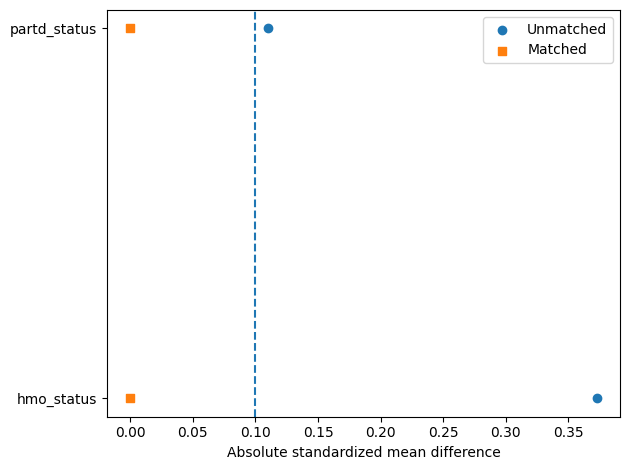

In [67]:
# Choose your RD sample
sub = ma_rd1_9.copy()

# # Covariates you want balanced (must be numeric)
# covariates = ["partd_status", "hmo_status"]  # add more if you want

# # Keep only rows with complete data needed for matching
# sub = sub.dropna(subset=covariates + ["treat"]).copy()

covariates = ["partd_status", "hmo_status"]
X = sub[covariates].to_numpy()
treat_vec = sub["treat"].astype(int).to_numpy()

# Mahalanobis NN matching (1:1)
V = np.cov(X, rowvar=False)
nn = NearestNeighbors(
    n_neighbors=1,
    metric="mahalanobis",
    metric_params={"V": V}
)
nn.fit(X[treat_vec == 0])

dist, idx = nn.kneighbors(X[treat_vec == 1])
control_matches = sub.loc[treat_vec == 0].iloc[idx[:, 0]].copy()
treated_matched = sub.loc[treat_vec == 1].copy()

matched = pd.concat(
    [treated_matched.reset_index(drop=True),
     control_matches.reset_index(drop=True)],
    axis=0
).reset_index(drop=True)
matched["treat"] = np.r_[np.ones(len(treated_matched)), np.zeros(len(control_matches))]

def smd(df, var, treat_col="treat"):
    g1 = df[df[treat_col] == 1][var]
    g0 = df[df[treat_col] == 0][var]
    m1, m0 = g1.mean(), g0.mean()
    s = np.sqrt(0.5 * (g1.var(ddof=1) + g0.var(ddof=1)))
    return (m1 - m0) / s

smd_before = [smd(sub, v) for v in covariates]
smd_after  = [smd(matched, v) for v in covariates]

fig, ax = plt.subplots()
y_pos = np.arange(len(covariates))
ax.scatter(np.abs(smd_before), y_pos, marker="o", label="Unmatched")
ax.scatter(np.abs(smd_after),  y_pos, marker="s", label="Matched")
ax.set_yticks(y_pos)
ax.set_yticklabels(covariates)
ax.set_xlabel("Absolute standardized mean difference")
ax.axvline(0.1, linestyle="--")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [68]:
sub = ma_rd1_9[ma_rd1_9["window1"]].copy()   # or window2

covariates = ["hmo_status", "partd_status"]

# Ensure numeric 0/1
for v in covariates:
    sub[v] = pd.to_numeric(sub[v], errors="coerce")

# Table: mean just below vs just above
summary = sub.groupby("treat")[covariates].mean().T
summary.columns = ["Below cutoff (treat=0)", "Above cutoff (treat=1)"]
summary["Difference (Above - Below)"] = summary["Above cutoff (treat=1)"] - summary["Below cutoff (treat=0)"]
summary

,Below cutoff (treat=0),Above cutoff (treat=1),Difference (Above - Below)
hmo_status,0.475000,0.808333,0.333333
partd_status,0.841667,0.791667,-0.050000


In [69]:
# Candidates: partc_score 2.5 or 3 with non-missing raw_rating and star_rating
candidates_mask_92 = (
    plan_year_9["raw_rating"].notna()
    & plan_year_9["star_rating"].isin([3.0, 3.5])
)
ma_25star_candidates_92 = plan_year_9.loc[candidates_mask_92].copy()

n_candidates_total_92 = len(ma_25star_candidates_92)

# Final sample: raw_rating in the range consistent with the star score
match_mask_92= (
    ma_25star_candidates_92["raw_rating"].between(3.0, 3.5)
    & (
        ((ma_25star_candidates_92["star_rating"] == 3.5) &
         (ma_25star_candidates_92["raw_rating"] >= 3.25))
        |
        ((ma_25star_candidates_92["star_rating"] == 3.0) &
         (ma_25star_candidates_92["raw_rating"] < 3.25))
    )
)
ma_25star_py_92 = ma_25star_candidates_92.loc[match_mask_92].copy()

n_25star_total_py_92 = len(ma_25star_py_92)

print("Obs with partc_score 3.0 or 3.5:", n_candidates_total_92)
print("Obs with raw_rating in the matching range:", n_25star_total_py_92)

ma_rd1_92 = ma_25star_py_92.copy()
ma_rd1_92["score"] = ma_rd1_92["raw_rating"] - 3.25
ma_rd1_92["treat"] = (ma_rd1_92["score"] >= 0).astype(int)
ma_rd1_92["window1"] = ma_rd1_92["score"].between(-0.175, 0.175)
ma_rd1_92["window2"] = ma_rd1_92["score"].between(-0.125, 0.125)
ma_rd1_92["score_treat"] = ma_rd1_92["score"] * ma_rd1_92["treat"]

star25_1_92 = smf.ols("enrollments ~ score + treat", data=ma_rd1_92).fit()
star25_2_92 = smf.ols("enrollments ~ score + treat", data=ma_rd1_92[ma_rd1_92["window1"]]).fit()
star25_3_92 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1_92[ma_rd1_92["window1"]]).fit()
star25_4_92 = smf.ols("enrollments ~ score + treat + score_treat", data=ma_rd1_92[ma_rd1_92["window2"]]).fit()

Obs with partc_score 3.0 or 3.5: 759
Obs with raw_rating in the matching range: 481


In [70]:
sub2 = ma_rd1_92[ma_rd1_92["window1"]].copy()   # or window2

covariates = ["hmo_status", "partd_status"]

# Ensure numeric 0/1
for v in covariates:
    sub2[v] = pd.to_numeric(sub2[v], errors="coerce")

# Table: mean just below vs just above
summary = sub2.groupby("treat")[covariates].mean().T
summary.columns = ["Below cutoff (treat=0)", "Above cutoff (treat=1)"]
summary["Difference (Above - Below)"] = summary["Above cutoff (treat=1)"] - summary["Below cutoff (treat=0)"]
summary

,Below cutoff (treat=0),Above cutoff (treat=1),Difference (Above - Below)
hmo_status,0.874419,0.50,-0.374419
partd_status,0.874419,0.85,-0.024419


## Question 10

Rounding up for star ratings leads to higher enrollment. 